# Cognifyz Data Science Internship
## Level 2 - Task 1: Table Booking and Online Delivery

### Objective

Analyze the relationship between table booking and online delivery features and restaurant ratings.

The analysis will examine:

- Availability of table booking
- Availability of online delivery
- Restaurant ratings based on these services
- The relationship between service availability and aggregate rating

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load the cleaned dataset

In [ ]:
df = pd.read_csv("Cleaned_Dataset.csv")


print("Dataset shape:", df.shape)

### Check the relevant columns

In [8]:
print("Relevant columns:")
df[
        [
            "Restaurant Name",
            "Has Table booking",
            "Has Online delivery",
            "Aggregate rating"
        ]
    ].head(10)


Relevant columns:


,Restaurant Name,Has Table booking,Has Online delivery,Aggregate rating
0,Le Petit Souffle,Yes,No,4.8
1,Izakaya Kikufuji,Yes,No,4.5
2,Heat - Edsa Shangri-La,Yes,No,4.4
3,Ooma,No,No,4.9
4,Sambo Kojin,Yes,No,4.8
5,Din Tai Fung,No,No,4.4
6,Buffet 101,Yes,No,4.0
7,Vikings,Yes,No,4.2
8,Spiral - Sofitel Philippine Plaza Manila,Yes,No,4.9
9,Locavore,Yes,No,4.8


### Calculate service availability percentages

In [10]:
table_booking_counts = df["Has Table booking"].value_counts()
online_delivery_counts = df["Has Online delivery"].value_counts()

table_booking_percentage = (
    df["Has Table booking"].value_counts(normalize=True) * 100
)

online_delivery_percentage = (
    df["Has Online delivery"].value_counts(normalize=True) * 100
)

print("Table Booking:")
print(table_booking_counts)
print("\nTable Booking Percentage:")
print(table_booking_percentage.round(2))

print("\nOnline Delivery:")
print(online_delivery_counts)
print("\nOnline Delivery Percentage:")
print(online_delivery_percentage.round(2))

Table Booking:
Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64

Table Booking Percentage:
Has Table booking
No     87.88
Yes    12.12
Name: proportion, dtype: float64

Online Delivery:
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Online Delivery Percentage:
Has Online delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64


### Create a service availability chart

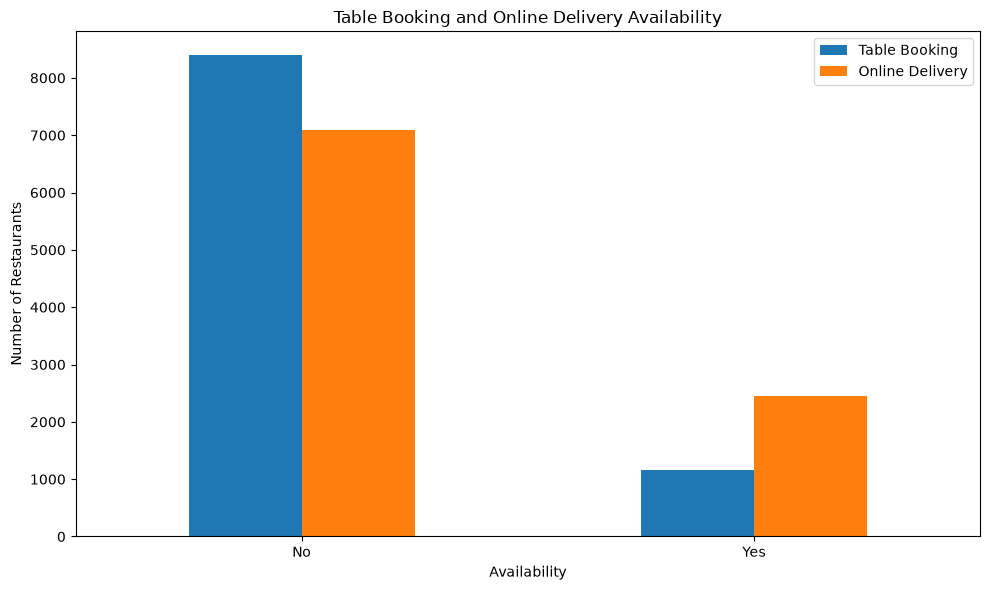

In [11]:
service_counts = pd.DataFrame({
    "Table Booking": df["Has Table booking"].value_counts(),
    "Online Delivery": df["Has Online delivery"].value_counts()
})

service_counts.plot(kind="bar", figsize=(10, 6))

plt.title("Table Booking and Online Delivery Availability")
plt.xlabel("Availability")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Compare ratings by service availability

In [12]:
table_booking_rating = df.groupby(
    "Has Table booking"
)["Aggregate rating"].mean()

online_delivery_rating = df.groupby(
    "Has Online delivery"
)["Aggregate rating"].mean()

print("Average rating by Table Booking availability:")
print(table_booking_rating.round(2))

print("\nAverage rating by Online Delivery availability:")
print(online_delivery_rating.round(2))

Average rating by Table Booking availability:
Has Table booking
No     2.56
Yes    3.44
Name: Aggregate rating, dtype: float64

Average rating by Online Delivery availability:
Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64


### Table Booking vs Average Rating

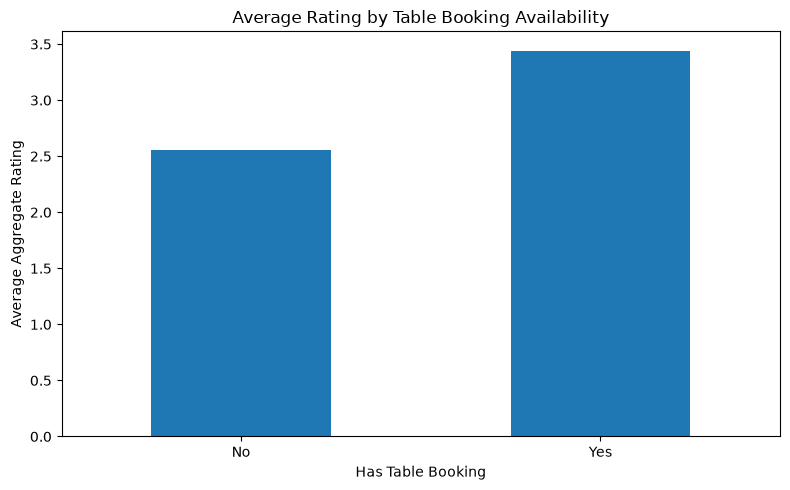

In [13]:
plt.figure(figsize=(8, 5))

table_booking_rating.plot(kind="bar")

plt.title("Average Rating by Table Booking Availability")
plt.xlabel("Has Table Booking")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Online Delivery vs Average Rating

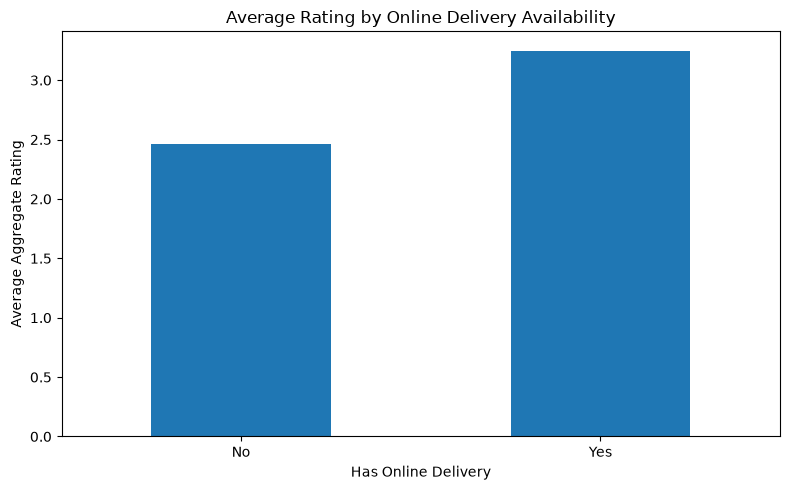

In [14]:
plt.figure(figsize=(8, 5))

online_delivery_rating.plot(kind="bar")

plt.title("Average Rating by Online Delivery Availability")
plt.xlabel("Has Online Delivery")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Calculate the rating differences

In [15]:
table_booking_difference = (
    table_booking_rating.get("Yes", 0)
    - table_booking_rating.get("No", 0)
)

online_delivery_difference = (
    online_delivery_rating.get("Yes", 0)
    - online_delivery_rating.get("No", 0)
)

print(
    "Difference in average rating "
    "(Table Booking: Yes - No):",
    round(table_booking_difference, 2)
)

print(
    "Difference in average rating "
    "(Online Delivery: Yes - No):",
    round(online_delivery_difference, 2)
)

Difference in average rating (Table Booking: Yes - No): 0.88
Difference in average rating (Online Delivery: Yes - No): 0.78


## Findings

### Table Booking

The availability of table booking was compared with the average aggregate rating of restaurants. The comparison shows how the average rating differs between restaurants that offer table booking and those that do not.

### Online Delivery

The availability of online delivery was compared with the average aggregate rating. The results show the difference in average ratings between restaurants that provide online delivery and those that do not.

### Overall Observation

The analysis provides a descriptive comparison between restaurant service availability and aggregate ratings. These comparisons show an association in the dataset, but they do not by themselves establish that table booking or online delivery causes higher or lower ratings.

In [16]:
summary_table = pd.DataFrame({
    "Table Booking": df.groupby("Has Table booking")["Aggregate rating"].mean(),
    "Online Delivery": df.groupby("Has Online delivery")["Aggregate rating"].mean()
})

display(summary_table.round(2))

,Table Booking,Online Delivery
No,2.56,2.47
Yes,3.44,3.25


## Conclusion

The analysis examined the availability of table booking and online delivery services among restaurants and compared their average aggregate ratings.

The results show differences in average ratings between restaurants with and without table booking, as well as between restaurants with and without online delivery.

These results describe an association between service availability and restaurant ratings in the dataset. However, the analysis does not establish a causal relationship, since other restaurant characteristics may also influence ratings.